# Factor Regression

This notebook is a cell-based version of `factor_regression.py`. It walks through factor preparation, cross-sectional regression, and factor effectiveness evaluation.

## Import Libraries

Set up the notebook path handling, import third-party dependencies, and load the local preprocessing helpers.

In [5]:
from pathlib import Path
import sys

notebook_dir = Path.cwd()
workspace_root = notebook_dir
while workspace_root != workspace_root.parent and not (workspace_root / "quant_strategy").exists():
    workspace_root = workspace_root.parent

chapter3_dir = workspace_root / "quant_strategy" / "strategy" / "chapter3"
for path in (workspace_root, chapter3_dir):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from atrader import *
import numpy as np
import pandas as pd
from pandas import DataFrame
import statsmodels.api as sm
import matplotlib.pyplot as plt

from MAD_factor import extreme_MAD
from neutralization import neutralization

## Define Helper Functions

Create the standardization and cross-sectional regression utilities used later in the analysis.

In [6]:
def standardization(df: DataFrame):
    return (df - df.mean()) / df.std()


def factortest_regression(factor: DataFrame, stock: DataFrame):
    factor_return = list()
    t_value = list()
    stock_return = -stock.diff(-1, axis=1).div(stock)
    factor = factor.fillna(0)
    stock_return = stock_return.fillna(0)

    for i in range(factor.columns.size - 1):
        result = sm.OLS(stock_return.iloc[:, i], factor.iloc[:, i]).fit()
        factor_return.append(list(result.params))
        t_value.append(list(result.tvalues))

    return np.c_[np.array(factor_return), np.array(t_value)]

## Load Factor Inputs

Set the analysis window, fetch the HS300 universe, and request the factor and market-cap data series.

In [7]:
start_date = "2025-04-01"
end_date = "2026-03-01"
code_list = list(get_code_list("hs300", date=start_date).code)

factor = get_factor_by_factor(
    factor="pb_ratio_ttm",
    target_list=code_list,
    begin_date=start_date,
    end_date=end_date,
)

mkv = get_factor_by_factor(
    factor="market_cap_3",
    target_list=code_list,
    begin_date=start_date,
    end_date=end_date,
)

## Align Monthly Factor Data

Transform the raw factor tables into month-end cross sections that match the regression schedule.

In [8]:
mkv.rename(columns={"market_cap_3": "mkv"}, inplace=True)
mkv = mkv.set_index(["date"]).T
factor = factor.set_index(["date"]).T

trading_days = get_trading_days("SSE", start_date, end_date)
months = np.vectorize(lambda x: x.month)(trading_days)
month_end = trading_days[pd.Series(months) != pd.Series(months).shift(-1)]
months_end_timestamp = [pd.Timestamp(x) for x in month_end]

factor = factor[months_end_timestamp].rename(index=str.lower)
mkv = mkv[months_end_timestamp].rename(index=str.lower)

factor.head()

date,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30,2026-02-27
szse.000001,0.42917,0.45474,0.47480,0.48109,0.46734,0.43980,0.43308,0.44418,0.43653,0.41434,0.41701
szse.000002,0.37134,0.36207,0.35007,0.35116,0.39279,0.39858,0.39033,0.33492,0.28948,0.30380,0.30131
szse.000063,2.12348,2.06697,2.16005,2.27972,2.97508,2.98818,2.81868,2.72982,2.45418,2.49634,2.50671
szse.000100,1.46968,1.51572,1.53343,1.64006,1.80967,1.68096,1.62083,1.53809,1.70732,1.82390,1.86903
szse.000157,1.11379,1.08340,1.09487,1.11304,1.10674,1.20612,1.22376,1.21028,1.29266,1.31363,1.49637


## Load Price Data

Retrieve monthly close prices and reshape them into the stock-by-time matrix used for returns.

In [9]:
data = get_kdata(
    target_list=code_list,
    frequency="month",
    fre_num=1,
    begin_date=start_date,
    end_date=end_date,
    fq=1,
    fill_up=True,
    df=True,
    sort_by_date=False,
)

close = data.pivot_table(values="close", index="code", columns="time")
code = sorted(set(list(data["code"])), key=list(data["code"]).index)
stock_close = close.loc[code]

stock_close.head()

time,2025-04-30 15:00:00,2025-05-30 15:00:00,2025-06-30 15:00:00,2025-07-31 15:00:00,2025-08-29 15:00:00,2025-09-30 15:00:00,2025-10-31 15:00:00,2025-11-28 15:00:00,2025-12-31 15:00:00,2026-01-30 15:00:00,2026-02-27 15:00:00
code,,,,,,,,,,,
szse.000001,10.91,11.56,12.07,12.23,12.05,11.34,11.32,11.61,11.41,10.83,10.90
szse.000002,6.81,6.64,6.42,6.44,6.79,6.89,6.27,5.38,4.65,4.88,4.84
szse.000063,31.94,31.09,32.49,34.29,45.44,45.64,43.46,42.09,37.84,38.49,38.65
szse.000100,4.15,4.28,4.33,4.40,4.64,4.31,4.31,4.09,4.54,4.85,4.97
szse.000157,7.33,7.13,7.23,7.35,7.35,8.01,8.17,8.08,8.63,8.77,9.99


## Preprocess Factors

Winsorize the factor values, standardize them, and compute the neutralized factor exposure.

In [10]:
factor_s = standardization(extreme_MAD(factor, 5.2))
factor_id = neutralization(factor_s, mkv)

factor_s.head()

date,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30,2026-02-27
szse.000001,-1.11072,-1.11665,-1.11953,-1.12567,-1.10007,-1.08876,-1.11007,-1.11123,-1.09461,-1.10194,-1.09528
szse.000002,-1.14001,-1.16413,-1.18238,-1.18895,-1.13148,-1.10471,-1.12752,-1.15824,-1.15481,-1.14520,-1.13928
szse.000063,-0.25245,-0.29069,-0.27044,-0.24966,-0.04333,-0.10306,-0.13627,-0.12787,-0.26851,-0.28714,-0.30069
szse.000100,-0.58363,-0.57310,-0.58616,-0.56121,-0.53443,-0.60868,-0.62523,-0.64059,-0.57430,-0.55030,-0.54316
szse.000157,-0.76391,-0.79458,-0.80712,-0.81788,-0.83063,-0.79235,-0.78732,-0.78163,-0.74408,-0.75000,-0.68487


## Run Cross-Sectional Regression

Estimate factor returns and t-values from the prepared factor matrix and monthly stock returns.

In [11]:
fr = factortest_regression(factor_s, stock_close)
df = pd.DataFrame(
    data=fr, index=factor_s.columns[0:-1], columns=["factor_return", "t_value"]
)

df.head()

,factor_return,t_value
date,,
2025-04-30,-0.01160,-3.46977
2025-05-30,-0.00250,-0.45814
2025-06-30,0.00000,0.01021
2025-07-31,0.06774,7.05462
2025-08-29,0.03378,3.93155


## Evaluate Factor Effectiveness

Summarize the regression results with diagnostic statistics and visualize cumulative factor returns.

t value abs mean: 3.178568556843909
t value > 2 ratio: 0.6
t value mean / std: 0.0075348123524439726
factor return mean: 0.007044763348416305


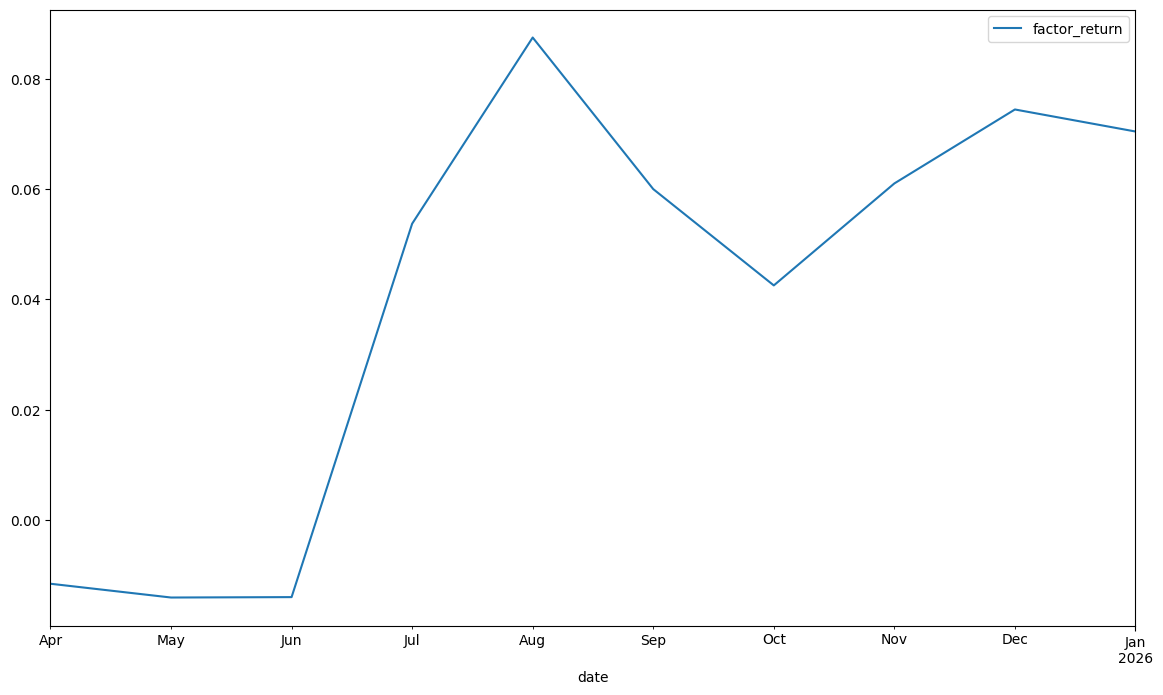

In [12]:
t_ma = df["t_value"].abs().mean()
print("t value abs mean: {}".format(t_ma))

t_ratio = len(df[(df["t_value"].abs() > 2)]) / len(df["t_value"])
print("t value > 2 ratio: {}".format(t_ratio))

t_div = abs(df["t_value"].mean()) / df["t_value"].std()
print("t value mean / std: {}".format(t_div))

factor_ma = df["factor_return"].mean()
print("factor return mean: {}".format(factor_ma))

fig = plt.figure(figsize=(14, 8))
df["factor_return"].cumsum().plot(kind="line", label="factor_return")
plt.legend()
plt.show()